# Лаб 5
Егорова Варвара Александровна, 408575, P3323

Необходимо реализовать простую нейронную сеть(не обязательно сверточную(!)) и обучить ее на датасете
- Каждый слой прописывается руками, перекладыванием матричек/тензоров из состояния А в состояние Б
- Возможные слои/классы, которые вам понадобятся для успешного закрытия лабы: Linear/Dense, Dropout, Conv2d, MaxPool2D, ReLU, Softmax, Flatten, Adam.
- В классе не должно быть волшебных истинно торчовских методов (т.е. ваш класс, который выглядит типа такого:
```
class Linear:
   def __init__(...):
        lin = nn.Linear(...)
```

не принимается. Все делаем ручками.
- Выводим графики нескольких моделей, с экспериментами (разный порядок слоев, разные входные/выходные параметры), выбираем свою лучшую модельку
- dataset https://www.kaggle.com/datasets/hojjatk/mnist-dataset

## Читаем датасет
(код взят с kaggle)

In [ ]:
import numpy as np
import struct
from array import array
from os.path  import join

class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath

    def read_images_labels(self, images_filepath, labels_filepath):
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())

        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img

        return images, labels

    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test)

In [ ]:
import kagglehub

path = kagglehub.dataset_download("hojjatk/mnist-dataset")

print("Path to dataset files:", path)

100%|██████████| 22.0M/22.0M [00:00<00:00, 169MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/hojjatk/mnist-dataset/versions/1


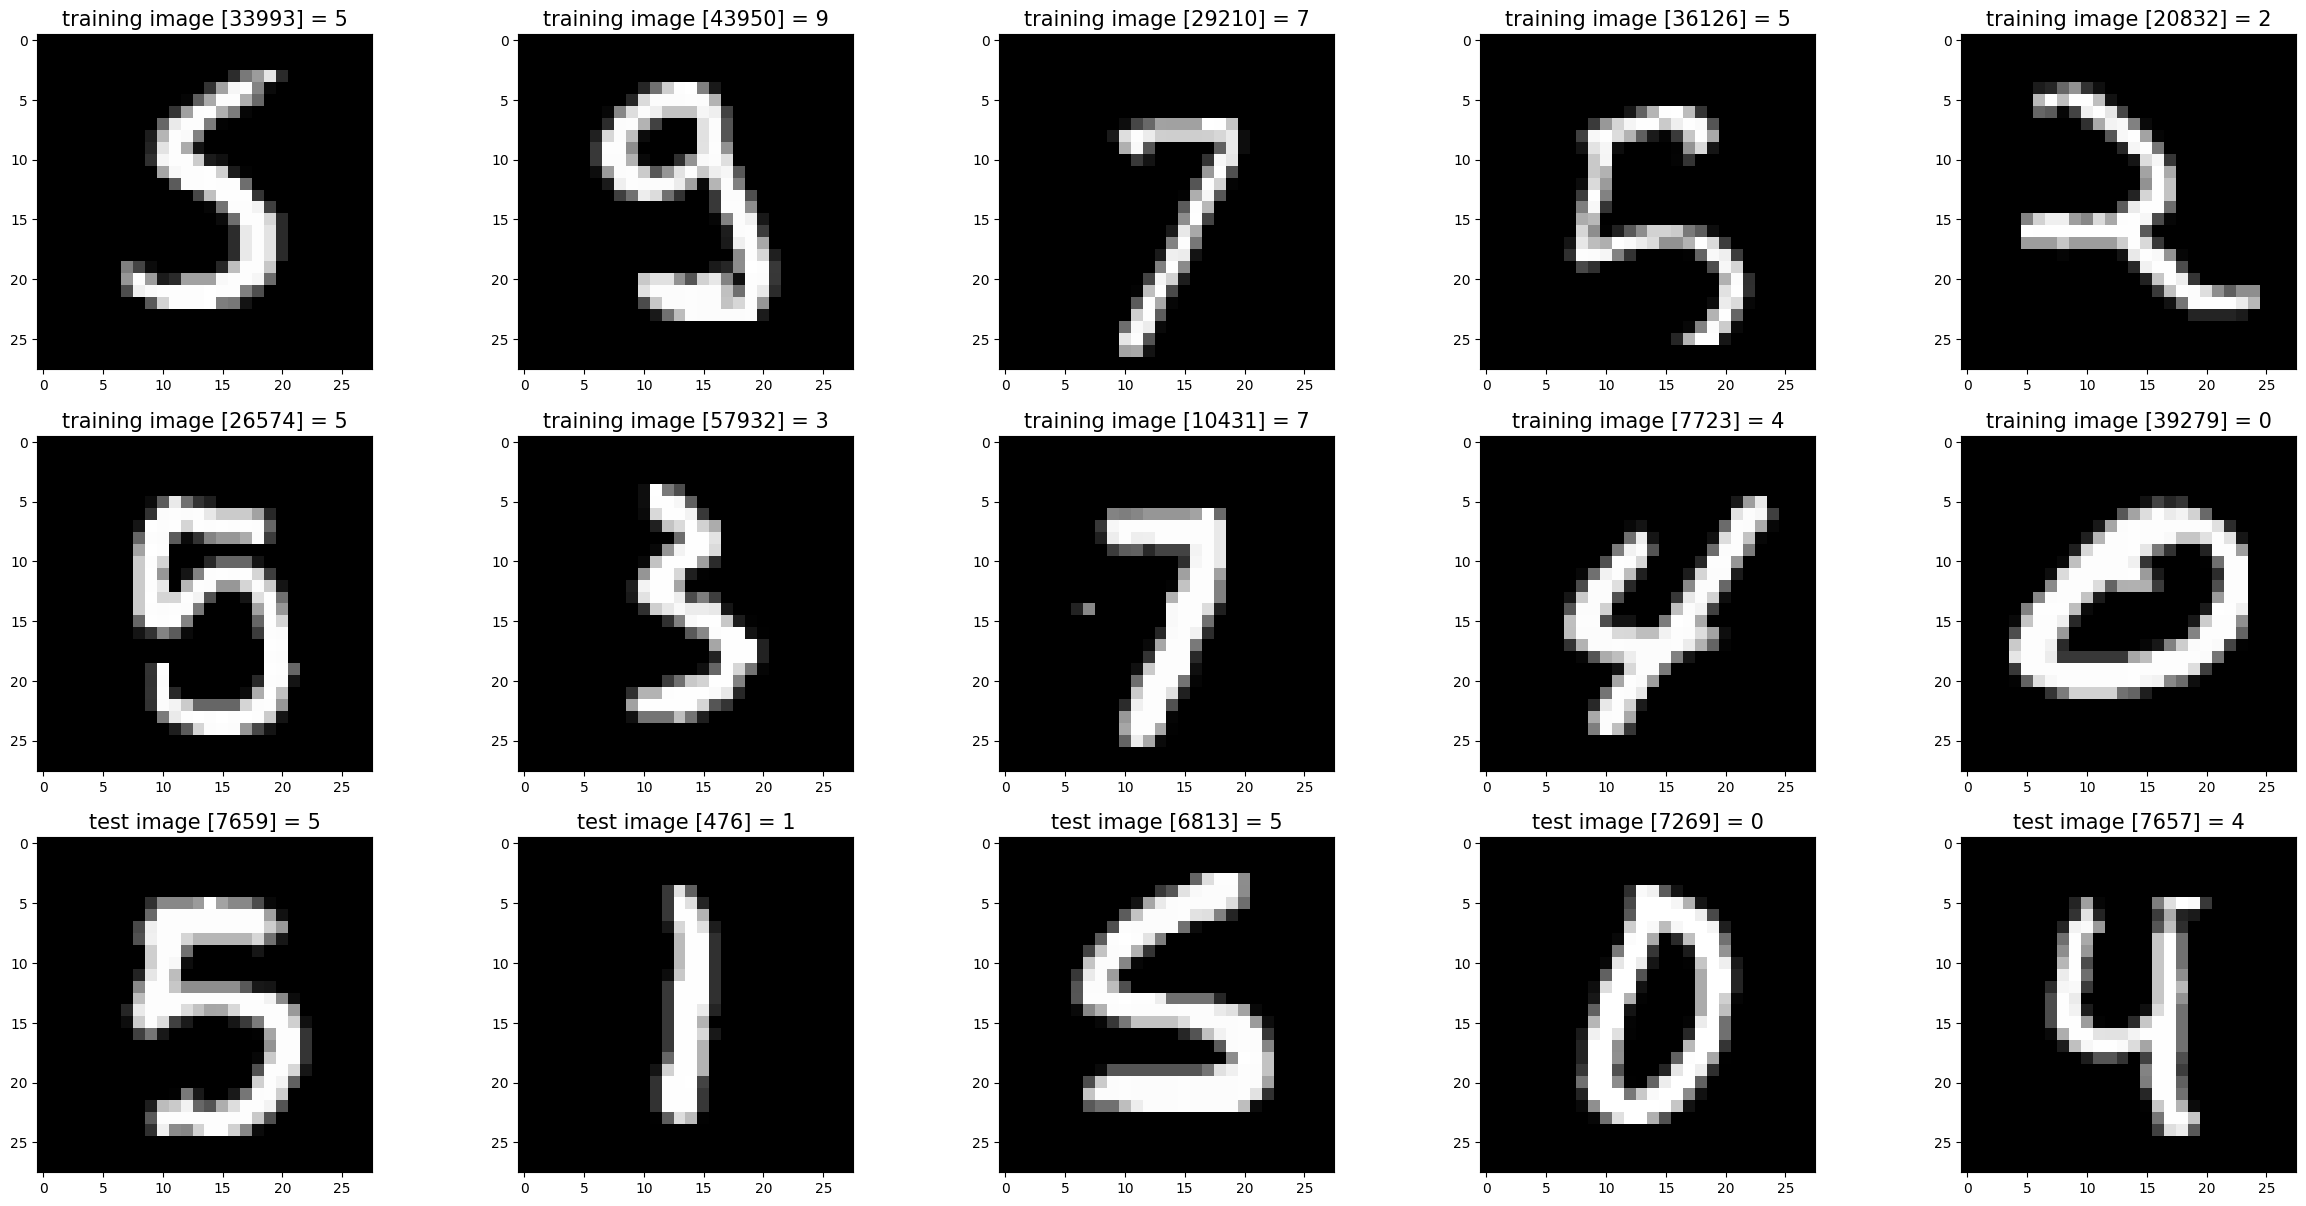

In [ ]:
%matplotlib inline
import random
import matplotlib.pyplot as plt

training_images_filepath = join(path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1
    for x in zip(images, title_texts):
        image = x[0]
        title_text = x[1]
        plt.subplot(rows, cols, index)
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);
        index += 1

mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

images_2_show = []
titles_2_show = []
for i in range(0, 10):
    r = random.randint(1, 60000)
    images_2_show.append(x_train[r])
    titles_2_show.append('training image [' + str(r) + '] = ' + str(y_train[r]))

for i in range(0, 5):
    r = random.randint(1, 10000)
    images_2_show.append(x_test[r])
    titles_2_show.append('test image [' + str(r) + '] = ' + str(y_test[r]))

show_images(images_2_show, titles_2_show)

## Чето пишем нейронку

### Слои

Линейный слой

In [ ]:
import torch

class Linear:
    def __init__(self, in_features, out_features):
        self.W = torch.randn(in_features, out_features) * 0.01
        self.b = torch.zeros(out_features)

        self.dW = torch.zeros_like(self.W)
        self.db = torch.zeros_like(self.b)

    def forward(self, X):
        self.X = X
        return X @ self.W + self.b

    def backward(self, grad_out):
        self.dW = self.X.T @ grad_out
        self.db = grad_out.sum(dim=0)

        return grad_out @ self.W.T

Relu

In [ ]:
import torch

class ReLU:
    def __init__(self):
        pass

    def forward(self, x):
        self.mask = x > 0
        return x * self.mask

    def backward(self, grad_out):
        return grad_out * self.mask


Flatten

In [ ]:
import torch

class Flatten:
    def __init__(self):
        pass

    def forward(self, x):
        self.input_shape = x.shape
        batch_size = x.shape[0]
        return x.view(batch_size, -1)

    def backward(self, grad_out):
        return grad_out.view(self.input_shape)


Softmax + CrossEntropyLoss

In [ ]:
import torch

class SoftmaxCrossEntropy:
    def __init__(self):
        pass

    def forward(self, logits, y_true):
        shifted_logits = logits - logits.max(dim=1, keepdim=True).values
        exp_logits = torch.exp(shifted_logits)
        probs = exp_logits / exp_logits.sum(dim=1, keepdim=True)

        self.probs = probs
        self.y_true = y_true
        self.batch_size = logits.shape[0]

        log_probs = torch.log(probs + 1e-9)
        loss = -log_probs[torch.arange(self.batch_size), y_true].mean()

        return loss

    def backward(self):
        grad = self.probs.clone()
        grad[torch.arange(self.batch_size), self.y_true] -= 1
        grad /= self.batch_size
        return grad


### Контейнер Model

In [ ]:
class Model:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def backward(self, grad):
        for layer in reversed(self.layers):
            grad = layer.backward(grad)
        return grad

    def parameters(self):
        params = []
        for layer in self.layers:
            if hasattr(layer, "W"):
                params.append((layer.W, layer.dW))
                params.append((layer.b, layer.db))
        return params

    def predict(self, x):
        with torch.no_grad():
            logits = self.forward(x)
            probs = torch.softmax(logits, dim=1)
            return torch.argmax(probs, dim=1)


### Оптимизатор Adam

In [ ]:
class Adam:
    def __init__(self, params, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params = params
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps

        self.t = 0
        self.m = []
        self.v = []

        for param, _ in self.params:
            self.m.append(torch.zeros_like(param))
            self.v.append(torch.zeros_like(param))

    def step(self):
        self.t += 1

        for i, (param, grad) in enumerate(self.params):
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * grad
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (grad ** 2)

            m_hat = self.m[i] / (1 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1 - self.beta2 ** self.t)

            param -= self.lr * m_hat / (torch.sqrt(v_hat) + self.eps)

    def zero_grad(self):
        for _, grad in self.params:
            grad.zero_()


### Цикл обучения

In [ ]:
import torch

def get_batches(X, y, batch_size, shuffle=True):
    n = X.shape[0]
    indices = torch.arange(n)

    if shuffle:
        indices = indices[torch.randperm(n)]

    for start in range(0, n, batch_size):
        end = start + batch_size
        batch_idx = indices[start:end]
        yield X[batch_idx], y[batch_idx]



def accuracy(logits, y_true):
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()



def train(model, criterion, optimizer, X_train, y_train, X_test, y_test, epochs=10, batch_size=64):
    optimizer.params = model.parameters()
    optimizer.step()
    train_losses = []
    train_accs = []
    test_accs = []

    for epoch in range(epochs):
        epoch_loss = 0.0
        epoch_acc = 0.0
        batches = 0

        # train
        for x_batch, y_batch in get_batches(X_train, y_train, batch_size):
            logits = model.forward(x_batch)
            loss = criterion.forward(logits, y_batch)

            grad = criterion.backward()
            model.backward(grad)

            optimizer.params = model.parameters()
            optimizer.step()
            optimizer.zero_grad()

            epoch_loss += loss
            epoch_acc += accuracy(logits, y_batch)
            batches += 1

        train_losses.append(epoch_loss / batches)
        train_accs.append(epoch_acc / batches)

        # test
        with torch.no_grad():
            logits_test = model.forward(X_test)
            test_acc = accuracy(logits_test, y_test)
            test_accs.append(test_acc)

        print(
            f"Epoch {epoch+1}/{epochs}: | "
            f"Loss: {train_losses[-1]:.4f} | "
            f"Train acc: {train_accs[-1]:.4f} | "
            f"Test acc: {test_acc:.4f}"
        )

    return train_losses, train_accs, test_accs


## ЭЭЭЭЭЭксперименты

In [ ]:
# чуть чуть подшаманим с датасетом (чтобы привести к тензорам)

import torch

x_train = np.array(x_train)
x_test = np.array(x_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

X_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

X_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

X_train /= 255.0
X_test /= 255.0

print(X_train.shape)
print(y_train.shape)

torch.Size([60000, 28, 28])
torch.Size([60000])


In [ ]:
# модель Flatten -> Linear(784, 128) -> ReLU -> Linear(128, 10)

model_1 = Model([
    Flatten(),
    Linear(784, 128),
    ReLU(),
    Linear(128, 10)
])

criterion = SoftmaxCrossEntropy()
optimizer_1 = Adam(model_1.parameters(), lr=0.001)

print("Треним первую модель")
res_1 = train(
    model_1,
    criterion,
    optimizer_1,
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=10,
    batch_size=64
)


Треним первую модель
Epoch 1/10: | Loss: 0.3830 | Train acc: 0.8962 | Test acc: 0.9405
Epoch 2/10: | Loss: 0.1737 | Train acc: 0.9502 | Test acc: 0.9572
Epoch 3/10: | Loss: 0.1212 | Train acc: 0.9645 | Test acc: 0.9632
Epoch 4/10: | Loss: 0.0928 | Train acc: 0.9728 | Test acc: 0.9696
Epoch 5/10: | Loss: 0.0728 | Train acc: 0.9784 | Test acc: 0.9756
Epoch 6/10: | Loss: 0.0588 | Train acc: 0.9829 | Test acc: 0.9774
Epoch 7/10: | Loss: 0.0482 | Train acc: 0.9857 | Test acc: 0.9773
Epoch 8/10: | Loss: 0.0407 | Train acc: 0.9876 | Test acc: 0.9794
Epoch 9/10: | Loss: 0.0332 | Train acc: 0.9899 | Test acc: 0.9784
Epoch 10/10: | Loss: 0.0279 | Train acc: 0.9919 | Test acc: 0.9795


In [ ]:
# модель Flatten -> Linear(784, 256) -> ReLU -> Linear(256, 10) - побольбше нейронов

model_2 = Model([
    Flatten(),
    Linear(784, 256),
    ReLU(),
    Linear(256, 10)
])

optimizer_2 = Adam(model_2.parameters(), lr=0.001)

print("Треним вторую модель")
res_2 = train(
    model_2,
    criterion,
    optimizer_2,
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=10,
    batch_size=64
)


Треним вторую модель
Epoch 1/10: | Loss: 0.3313 | Train acc: 0.9072 | Test acc: 0.9519
Epoch 2/10: | Loss: 0.1376 | Train acc: 0.9600 | Test acc: 0.9672
Epoch 3/10: | Loss: 0.0927 | Train acc: 0.9720 | Test acc: 0.9727
Epoch 4/10: | Loss: 0.0659 | Train acc: 0.9803 | Test acc: 0.9758
Epoch 5/10: | Loss: 0.0496 | Train acc: 0.9848 | Test acc: 0.9761
Epoch 6/10: | Loss: 0.0394 | Train acc: 0.9880 | Test acc: 0.9749
Epoch 7/10: | Loss: 0.0301 | Train acc: 0.9910 | Test acc: 0.9756
Epoch 8/10: | Loss: 0.0235 | Train acc: 0.9927 | Test acc: 0.9794
Epoch 9/10: | Loss: 0.0184 | Train acc: 0.9947 | Test acc: 0.9786
Epoch 10/10: | Loss: 0.0146 | Train acc: 0.9957 | Test acc: 0.9787


In [ ]:
# модель Flatten -> Linear(784, 128) -> ReLU -> Linear(128, 64) -> RelU -> Linear(64, 10) - плюс скрытый слой

model_3 = Model([
    Flatten(),
    Linear(784, 128),
    ReLU(),
    Linear(128, 64),
    ReLU(),
    Linear(64, 10)
])

optimizer_3 = Adam(model_3.parameters(), lr=0.001)

print("Треним третью модель")
res_3 = train(
    model_3,
    criterion,
    optimizer_3,
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=10,
    batch_size=64
)

Треним третью модель
Epoch 1/10: | Loss: 0.4694 | Train acc: 0.8581 | Test acc: 0.9270
Epoch 2/10: | Loss: 0.1955 | Train acc: 0.9426 | Test acc: 0.9563
Epoch 3/10: | Loss: 0.1289 | Train acc: 0.9613 | Test acc: 0.9652
Epoch 4/10: | Loss: 0.0945 | Train acc: 0.9715 | Test acc: 0.9621
Epoch 5/10: | Loss: 0.0753 | Train acc: 0.9766 | Test acc: 0.9701
Epoch 6/10: | Loss: 0.0608 | Train acc: 0.9805 | Test acc: 0.9730
Epoch 7/10: | Loss: 0.0496 | Train acc: 0.9843 | Test acc: 0.9695
Epoch 8/10: | Loss: 0.0396 | Train acc: 0.9876 | Test acc: 0.9750
Epoch 9/10: | Loss: 0.0343 | Train acc: 0.9887 | Test acc: 0.9765
Epoch 10/10: | Loss: 0.0276 | Train acc: 0.9917 | Test acc: 0.9778


Посмотрим на графиках

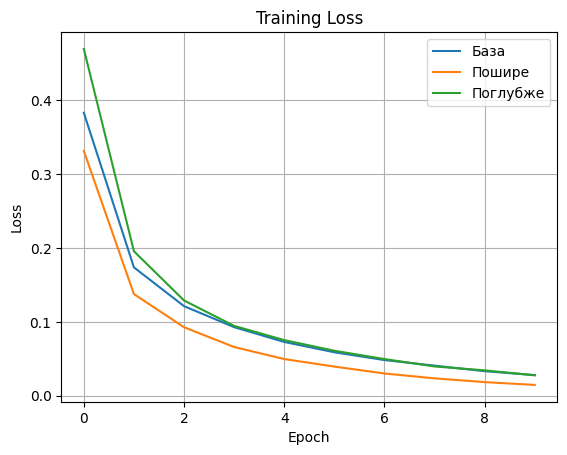

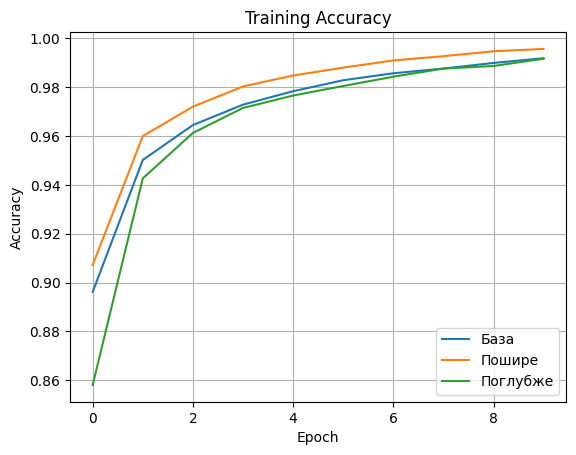

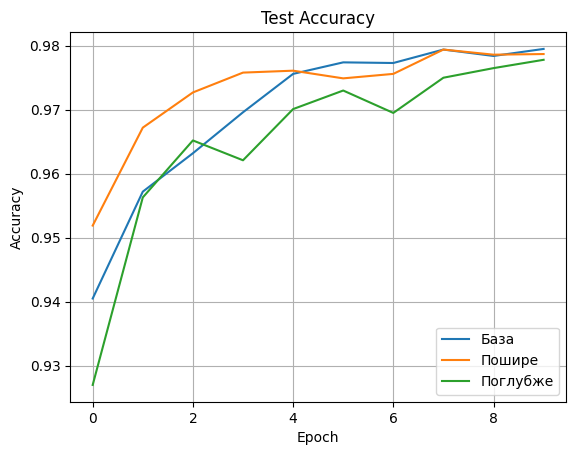

In [ ]:
import matplotlib.pyplot as plt

results = {
    "База": res_1,
    "Пошире": res_2,
    "Поглубже": res_3
}

plt.figure()
for name, (losses, _, _) in results.items():
    plt.plot(losses, label=name)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
for name, (_, train_accs, _) in results.items():
    plt.plot(train_accs, label=name)

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
for name, (_, _, test_accs) in results.items():
    plt.plot(test_accs, label=name)

plt.title("Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Итак тестим ручные рисунки
для тестов берем модель 2

In [ ]:
from PIL import Image
import numpy as np
import torch

def preprocess_image(path):
    img = Image.open(path).convert("L")
    img_np = np.array(img).astype(np.float32) / 255.0

    mask = img_np > 0.1
    coords = np.argwhere(mask)

    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1

    digit = img_np[y0:y1, x0:x1]

    h, w = digit.shape
    scale = 20.0 / max(h, w)
    new_h, new_w = int(h * scale), int(w * scale)
    digit_resized = np.array(Image.fromarray(digit).resize((new_w, new_h), Image.BILINEAR))

    canvas = np.zeros((28, 28), dtype=np.float32)
    top = (28 - new_h) // 2
    left = (28 - new_w) // 2
    canvas[top:top+new_h, left:left+new_w] = digit_resized

    img_tensor = torch.tensor(canvas).unsqueeze(0)

    return img_tensor

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

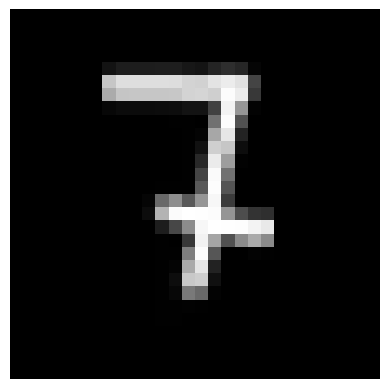

In [ ]:
img = preprocess_image("digit.png")

plt.imshow(img[0], cmap="gray")
plt.axis("off")

In [ ]:
pred_class = model_2.predict(img)
print("Предсказанный класс:", pred_class.item())

Предсказанный класс: 7


Попробуем сделать модель и пошире и поглубже

In [ ]:
model_4 = Model([
    Flatten(),
    Linear(784, 256),
    ReLU(),
    Linear(256, 64),
    ReLU(),
    Linear(64, 10)
])

optimizer_4 = Adam(model_4.parameters(), lr=0.001)

print("Треним четвертую модель")
res_4 = train(
    model_4,
    criterion,
    optimizer_4,
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=10,
    batch_size=60
)

Треним четвертую модель
Epoch 1/10: | Loss: 0.4267 | Train acc: 0.8713 | Test acc: 0.9314
Epoch 2/10: | Loss: 0.1677 | Train acc: 0.9514 | Test acc: 0.9611
Epoch 3/10: | Loss: 0.1097 | Train acc: 0.9671 | Test acc: 0.9690
Epoch 4/10: | Loss: 0.0802 | Train acc: 0.9755 | Test acc: 0.9753
Epoch 5/10: | Loss: 0.0591 | Train acc: 0.9822 | Test acc: 0.9736
Epoch 6/10: | Loss: 0.0468 | Train acc: 0.9855 | Test acc: 0.9768
Epoch 7/10: | Loss: 0.0362 | Train acc: 0.9885 | Test acc: 0.9776
Epoch 8/10: | Loss: 0.0321 | Train acc: 0.9897 | Test acc: 0.9782
Epoch 9/10: | Loss: 0.0242 | Train acc: 0.9924 | Test acc: 0.9761
Epoch 10/10: | Loss: 0.0196 | Train acc: 0.9937 | Test acc: 0.9782


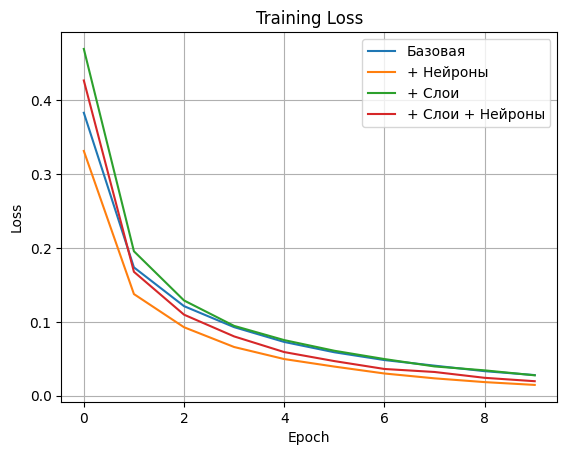

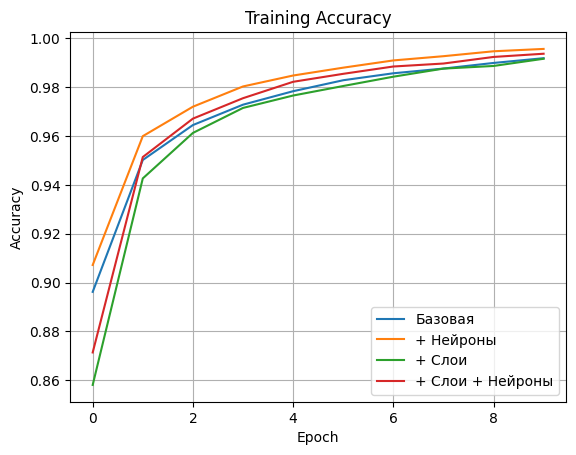

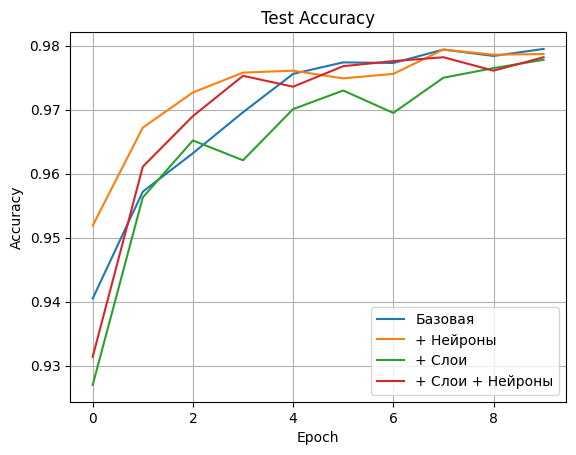

In [ ]:
import matplotlib.pyplot as plt

results = {
    "Базовая": res_1,
    "+ Нейроны": res_2,
    "+ Слои": res_3,
    "+ Слои + Нейроны": res_4
}

plt.figure()
for name, (losses, _, _) in results.items():
    plt.plot(losses, label=name)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
for name, (_, train_accs, _) in results.items():
    plt.plot(train_accs, label=name)

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
for name, (_, _, test_accs) in results.items():
    plt.plot(test_accs, label=name)

plt.title("Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
files = ["digits/1.png", "digits/2.png",
         "digits/3.png", "digits/4.png",
         "digits/5.png", "digits/6.png",
         "digits/7.png", "digits/8.png",
         "digits/9.png", "digits/0.png"]

In [ ]:
for file in files:
  print(f"File: {file}")
  img = preprocess_image(file)

  pred_class = model_2.predict(img)
  print("Предсказанный класс (2 модель):", pred_class.item())
  pred_class = model_4.predict(img)
  print("Предсказанный класс (4 модель):", pred_class.item())

File: digits/1.png
Предсказанный класс (2 модель): 1
Предсказанный класс (4 модель): 1
File: digits/2.png
Предсказанный класс (2 модель): 2
Предсказанный класс (4 модель): 2
File: digits/3.png
Предсказанный класс (2 модель): 3
Предсказанный класс (4 модель): 3
File: digits/4.png
Предсказанный класс (2 модель): 4
Предсказанный класс (4 модель): 4
File: digits/5.png
Предсказанный класс (2 модель): 5
Предсказанный класс (4 модель): 5
File: digits/6.png
Предсказанный класс (2 модель): 6
Предсказанный класс (4 модель): 6
File: digits/7.png
Предсказанный класс (2 модель): 7
Предсказанный класс (4 модель): 7
File: digits/8.png
Предсказанный класс (2 модель): 8
Предсказанный класс (4 модель): 8
File: digits/9.png
Предсказанный класс (2 модель): 9
Предсказанный класс (4 модель): 9
File: digits/0.png
Предсказанный класс (2 модель): 2
Предсказанный класс (4 модель): 0


Предсказанный класс (2 модель): 5
Предсказанный класс (4 модель): 5


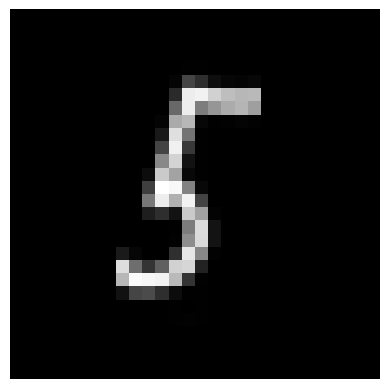

In [ ]:
img = preprocess_image("digit.png")

plt.imshow(img[0], cmap="gray")
plt.axis("off")

pred_class = model_2.predict(img)
print("Предсказанный класс (2 модель):", pred_class.item())
pred_class = model_4.predict(img)
print("Предсказанный класс (4 модель):", pred_class.item())

In [ ]:
def softmax(x):
    x = x - x.max(dim=1, keepdim=True).values
    exp_x = torch.exp(x)
    return exp_x / exp_x.sum(dim=1, keepdim=True)


def compute_roc_auc(model, X, y, class_id):
    with torch.no_grad():
        logits = model.forward(X)
        probs = softmax(logits)

    y_true = (y == class_id).int()
    y_score = probs[:, class_id]

    thresholds = torch.linspace(0, 1, 100)
    tpr_list, fpr_list = [], []

    for t in thresholds:
        y_pred = (y_score >= t).int()

        TP = ((y_pred == 1) & (y_true == 1)).sum().item()
        FP = ((y_pred == 1) & (y_true == 0)).sum().item()
        TN = ((y_pred == 0) & (y_true == 0)).sum().item()
        FN = ((y_pred == 0) & (y_true == 1)).sum().item()

        TPR = TP / (TP + FN + 1e-8)
        FPR = FP / (FP + TN + 1e-8)

        tpr_list.append(TPR)
        fpr_list.append(FPR)

    auc = 0.0
    for i in range(1, len(fpr_list)):
        auc += (fpr_list[i] - fpr_list[i-1]) * (tpr_list[i] + tpr_list[i-1]) / 2

    return fpr_list, tpr_list, abs(auc)

AUC: 0.9979


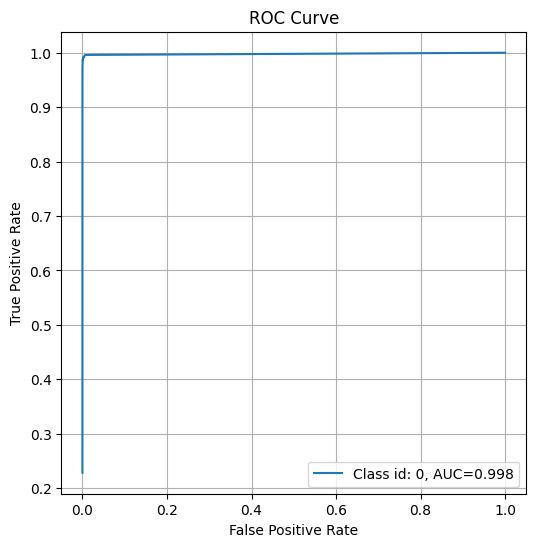

AUC: 0.9992


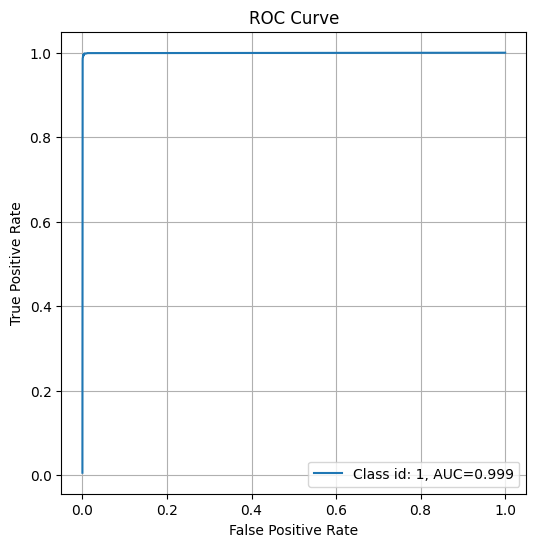

AUC: 0.9969


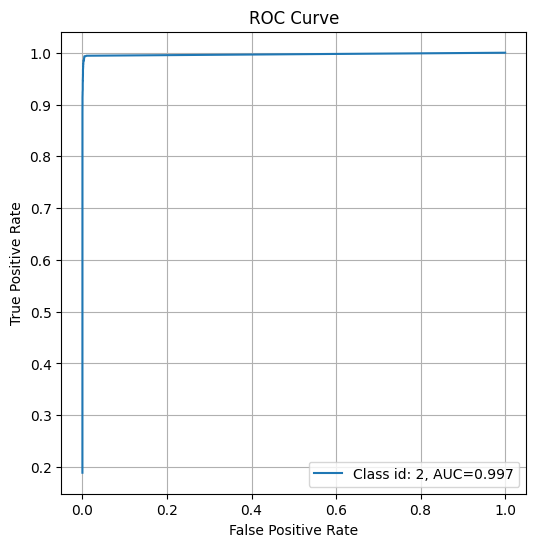

AUC: 0.9983


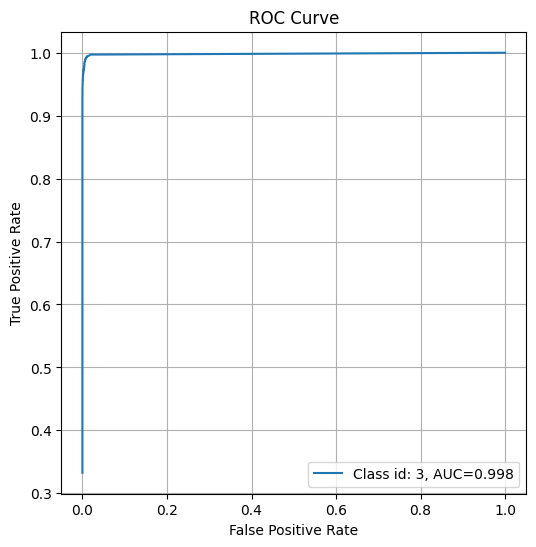

AUC: 0.9961


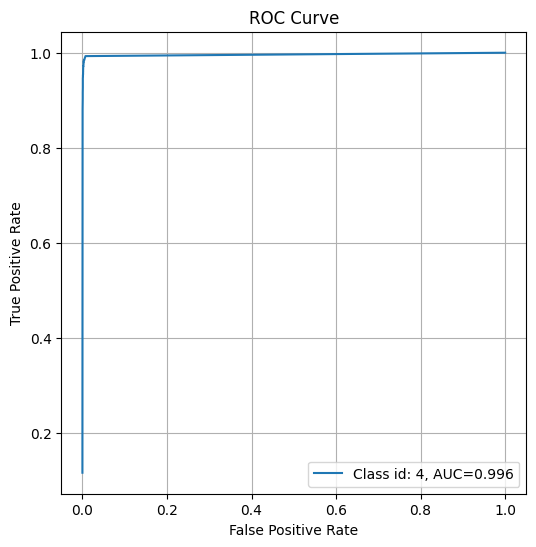

AUC: 0.9986


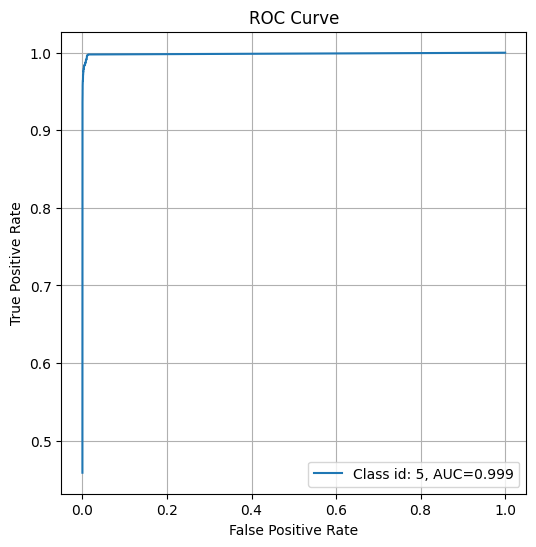

AUC: 0.9973


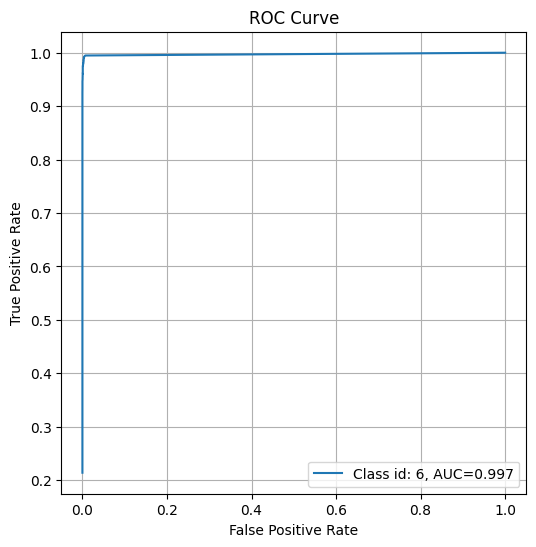

AUC: 0.9986


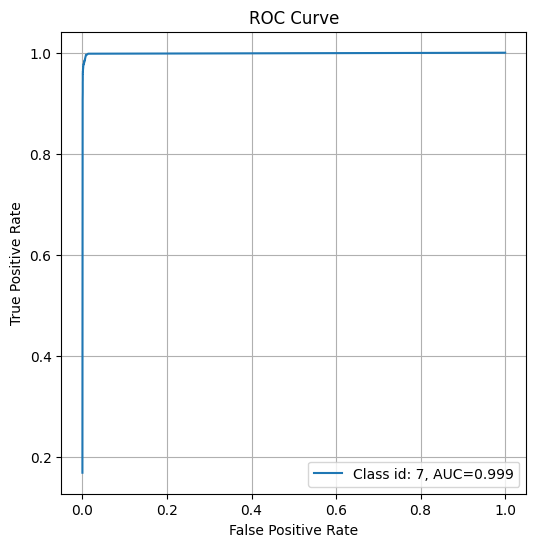

AUC: 0.9936


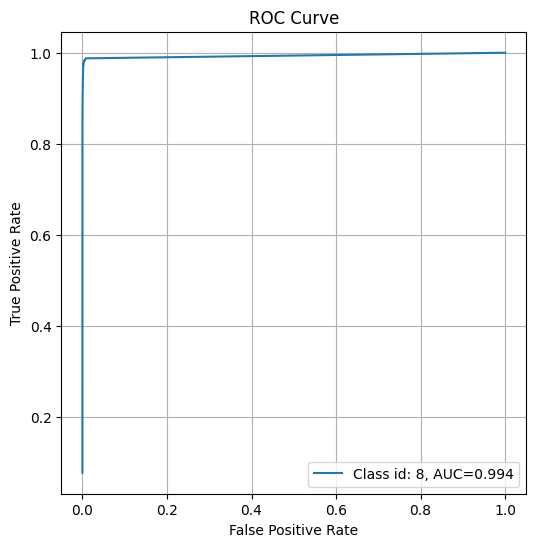

AUC: 0.9961


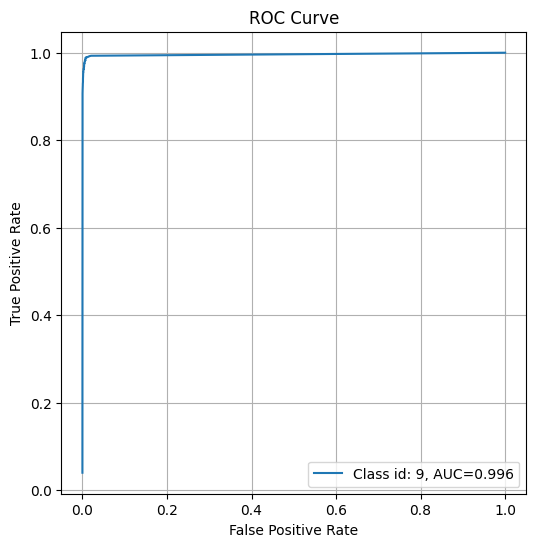

In [ ]:
class_id = list(range (10))

for i in class_id:
  fpr, tpr, auc = compute_roc_auc(
    model_4,
    X_test,
    y_test,
    i
  )

  print(f"AUC: {auc:.4f}")

  plt.figure(figsize=(6, 6))
  plt.plot(fpr, tpr, label=f"Class id: {i}, AUC={auc:.3f}")
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.title("ROC Curve")
  plt.legend()
  plt.grid()
  plt.show()